## Librerías y carga de datos
Cargamos el dataset original de 923 startups con 49 columnas desde Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'figure.dpi': 150})

df = pd.read_csv('../data/raw/startup_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (923, 49)


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


## Información general del dataset
Revisamos tipos de datos, cantidad de nulos y estructura general.

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 14  age_first_

El dataset tiene 49 columnas - 28 numéricas (int64), 7 float64 y 14 object. Las columnas con más nulos son `Unnamed: 6` (493 nulos), `closed_at` (588 nulos) y las columnas de milestones (152 nulos). Estas se manejarán en el preprocesamiento.

In [3]:
print(df['status'].value_counts())
print()
print(df['labels'].value_counts())

status
acquired    597
closed      326
Name: count, dtype: int64

labels
1    597
0    326
Name: count, dtype: int64


## Distribución de la variable objetivo
Analizamos el desbalance entre startups exitosas (acquired) y cerradas (closed).

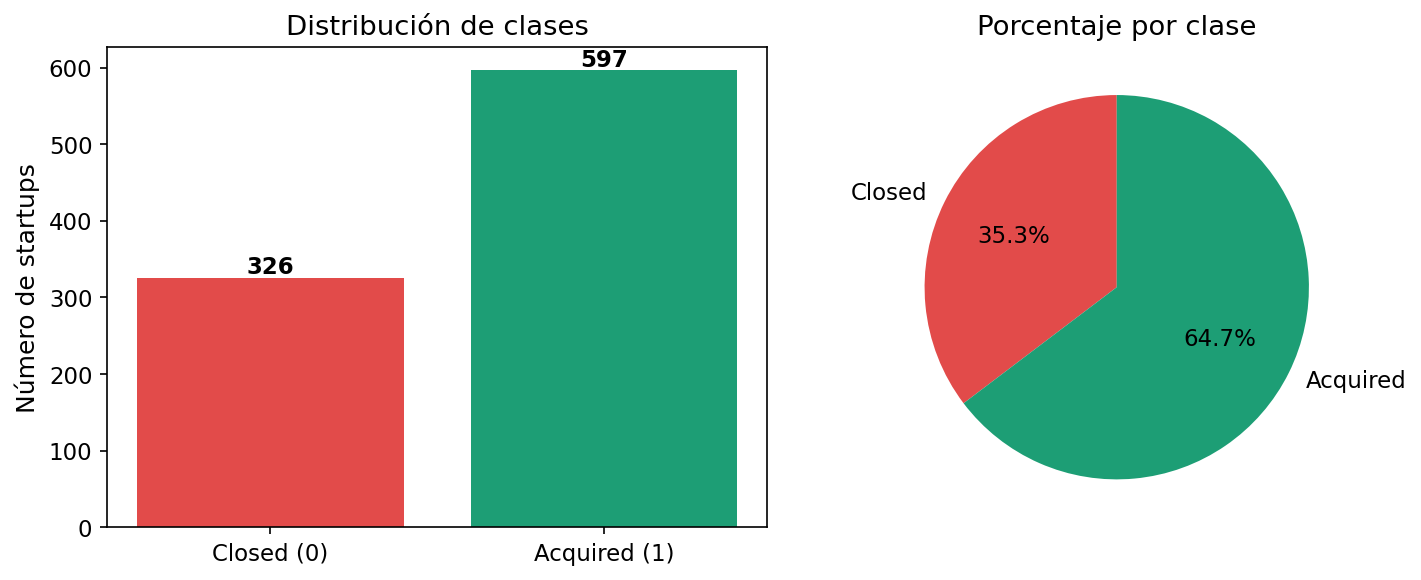

Figura guardada.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo
axes[0].bar(['Closed (0)', 'Acquired (1)'], 
            df['labels'].value_counts().sort_index().values,
            color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Número de startups')
for i, v in enumerate(df['labels'].value_counts().sort_index().values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Porcentaje
pct = df['labels'].value_counts(normalize=True).sort_index() * 100
axes[1].pie(pct.values, labels=['Closed', 'Acquired'], 
            colors=['#E24B4A', '#1D9E75'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Porcentaje por clase')

plt.tight_layout()
plt.savefig('../docs/fig_01_class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figura guardada.')

El dataset presenta un desbalance moderado - 64.7% acquired vs 35.3% closed. No es tan extremo como otros problemas de clasificación, pero justifica aplicar SMOTE en el preprocesamiento para no sesgar el modelo hacia la clase mayoritaria.

## Análisis por sector
Exploramos qué sectores concentran más startups y cuáles tienen mayor tasa de éxito.

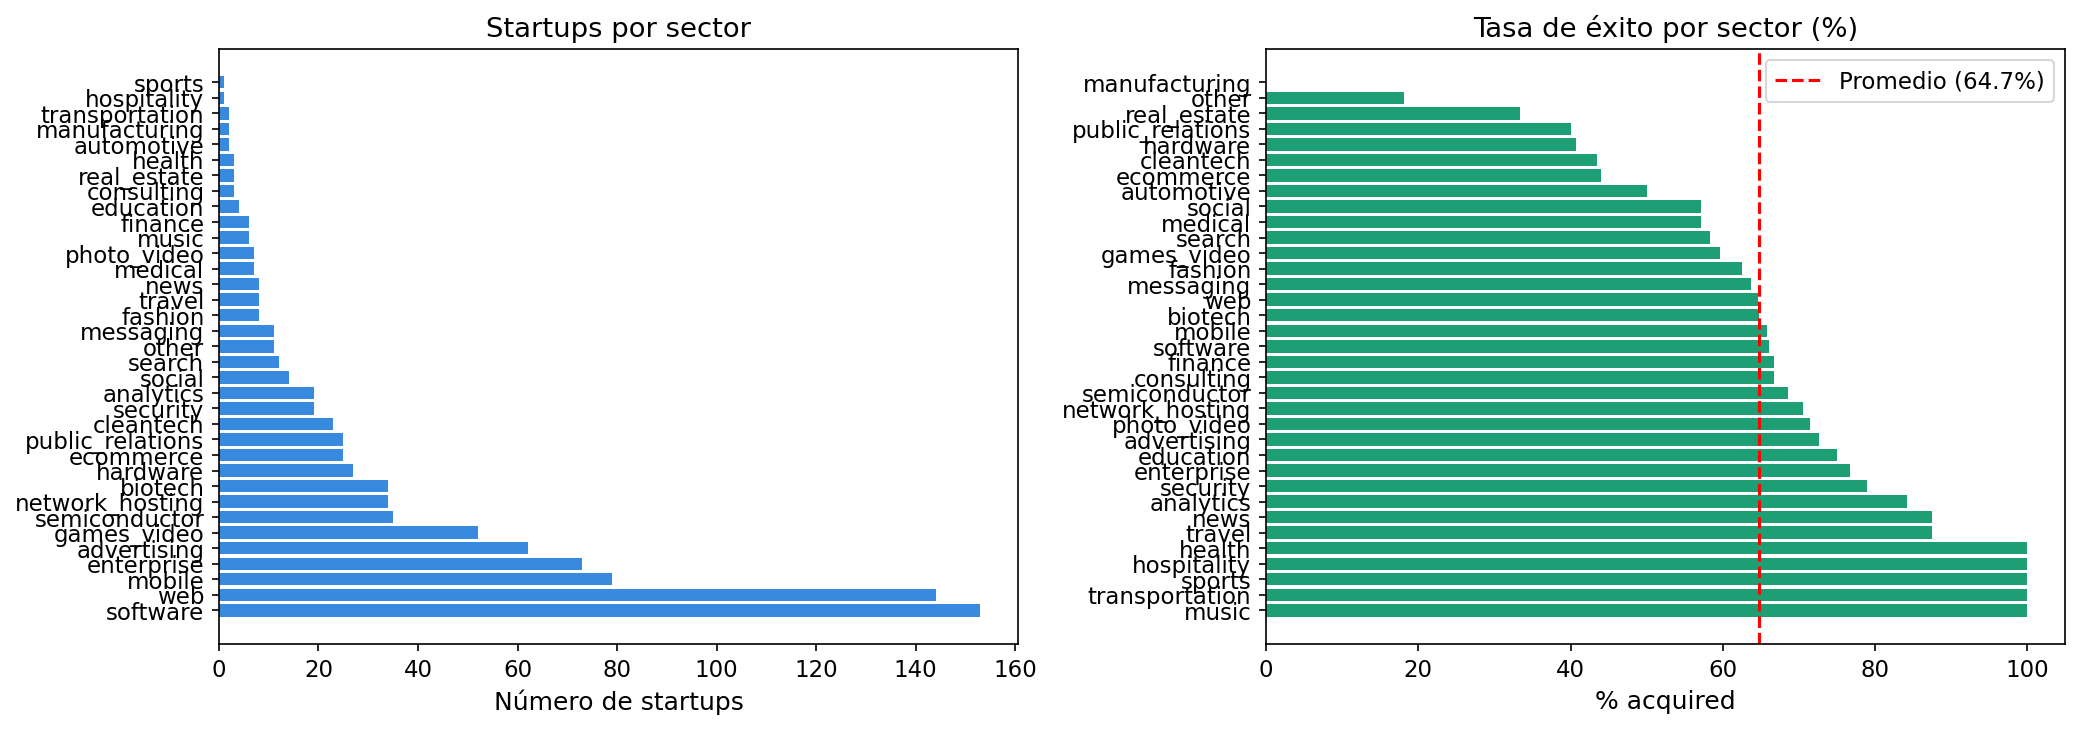

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por categoría
cat_counts = df['category_code'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='#378ADD')
axes[0].set_title('Startups por sector')
axes[0].set_xlabel('Número de startups')

# Tasa de éxito por categoría
success_rate = df.groupby('category_code')['labels'].mean().sort_values(ascending=False)
axes[1].barh(success_rate.index, success_rate.values * 100, color='#1D9E75')
axes[1].set_title('Tasa de éxito por sector (%)')
axes[1].set_xlabel('% acquired')
axes[1].axvline(x=df['labels'].mean() * 100, color='red', 
                linestyle='--', label=f'Promedio ({df["labels"].mean()*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/fig_02_category_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

Software y web dominan en cantidad con más de 150 y 80 startups respectivamente. Sin embargo, sectores con pocas muestras como music, transportation y sports muestran tasas de éxito del 100%, lo que puede deberse al tamaño pequeño de muestra más que a una ventaja real del sector.

## Análisis de financiación y relaciones
Comparamos las variables de financiación entre startups exitosas y cerradas.

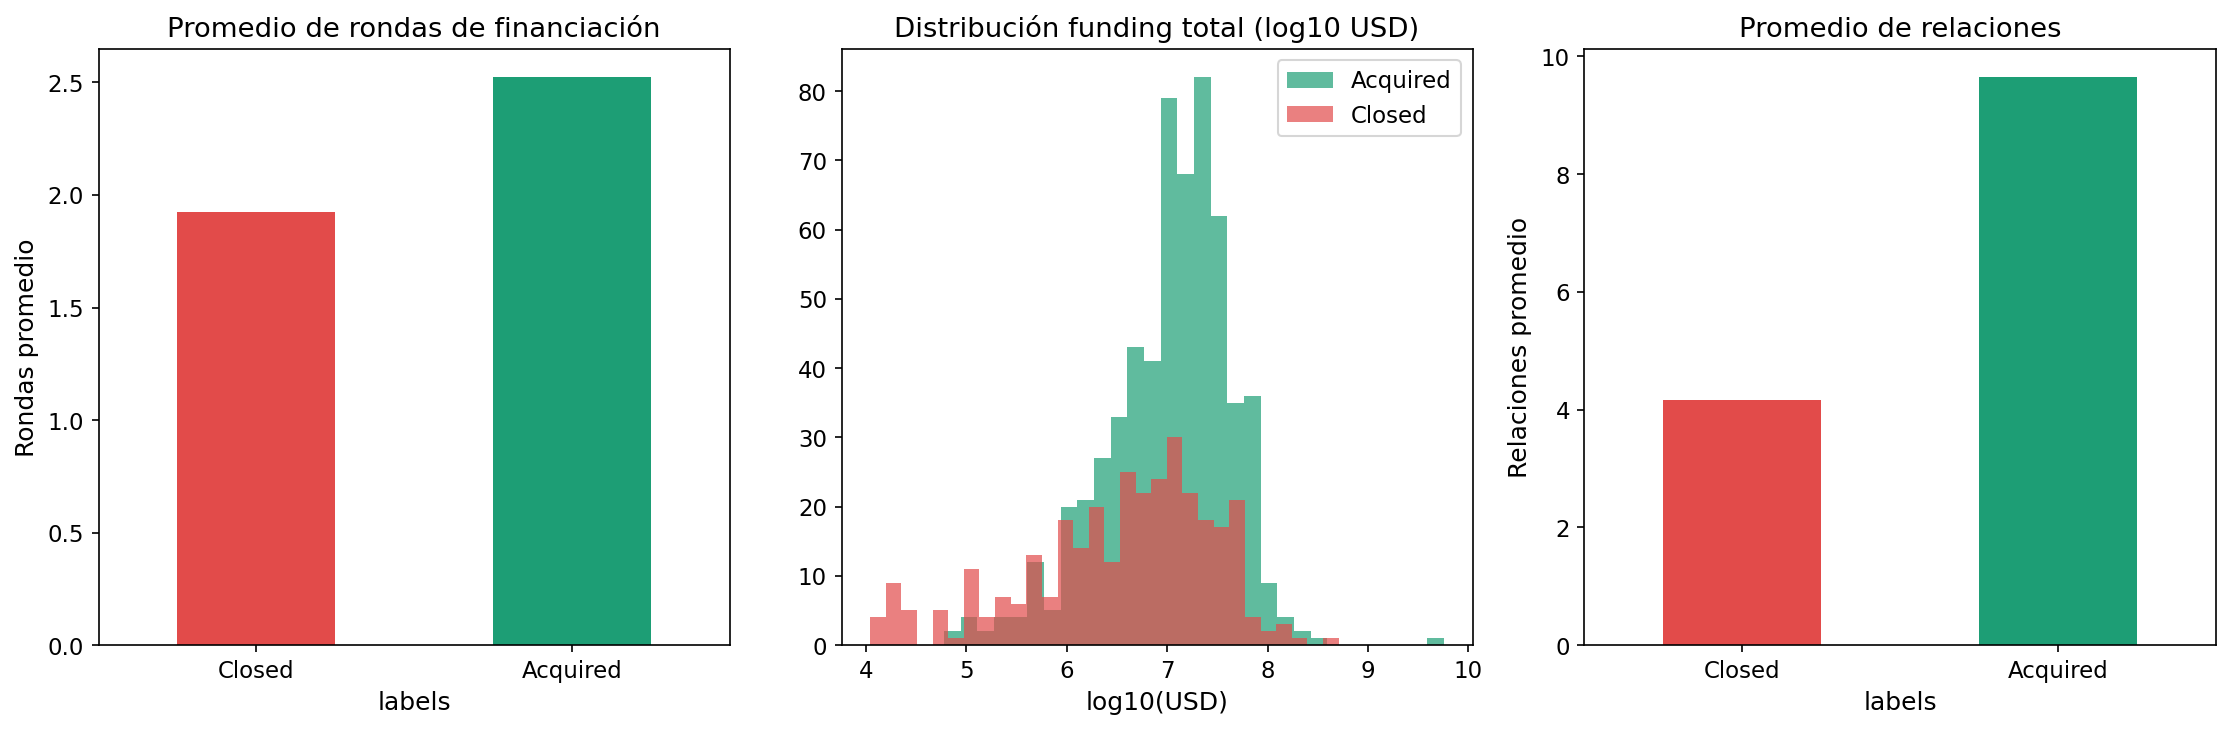

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Funding rounds por clase
df.groupby('labels')['funding_rounds'].mean().plot(
    kind='bar', ax=axes[0], color=['#E24B4A', '#1D9E75'], rot=0)
axes[0].set_title('Promedio de rondas de financiación')
axes[0].set_xticklabels(['Closed', 'Acquired'])
axes[0].set_ylabel('Rondas promedio')

# Funding total por clase (log scale)
df_plot = df.copy()
df_plot['funding_total_usd'] = df_plot['funding_total_usd'].replace(0, 1)
acquired = df_plot[df_plot['labels']==1]['funding_total_usd']
closed   = df_plot[df_plot['labels']==0]['funding_total_usd']
axes[1].hist(np.log10(acquired), bins=30, alpha=0.7, color='#1D9E75', label='Acquired')
axes[1].hist(np.log10(closed),   bins=30, alpha=0.7, color='#E24B4A', label='Closed')
axes[1].set_title('Distribución funding total (log10 USD)')
axes[1].set_xlabel('log10(USD)')
axes[1].legend()

# Relaciones por clase
df.groupby('labels')['relationships'].mean().plot(
    kind='bar', ax=axes[2], color=['#E24B4A', '#1D9E75'], rot=0)
axes[2].set_title('Promedio de relaciones')
axes[2].set_xticklabels(['Closed', 'Acquired'])
axes[2].set_ylabel('Relaciones promedio')

plt.tight_layout()
plt.savefig('../docs/fig_03_funding_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

Las startups acquired tienen en promedio 2.5 rondas de financiación vs 1.9 de las closed. La diferencia más notable está en `relationships` - las acquired tienen más del doble de relaciones en promedio, sugiriendo que la red de contactos es un factor crítico de éxito.

## Correlación con el target
Identificamos qué features numéricas tienen mayor poder predictivo sobre el éxito de la startup.

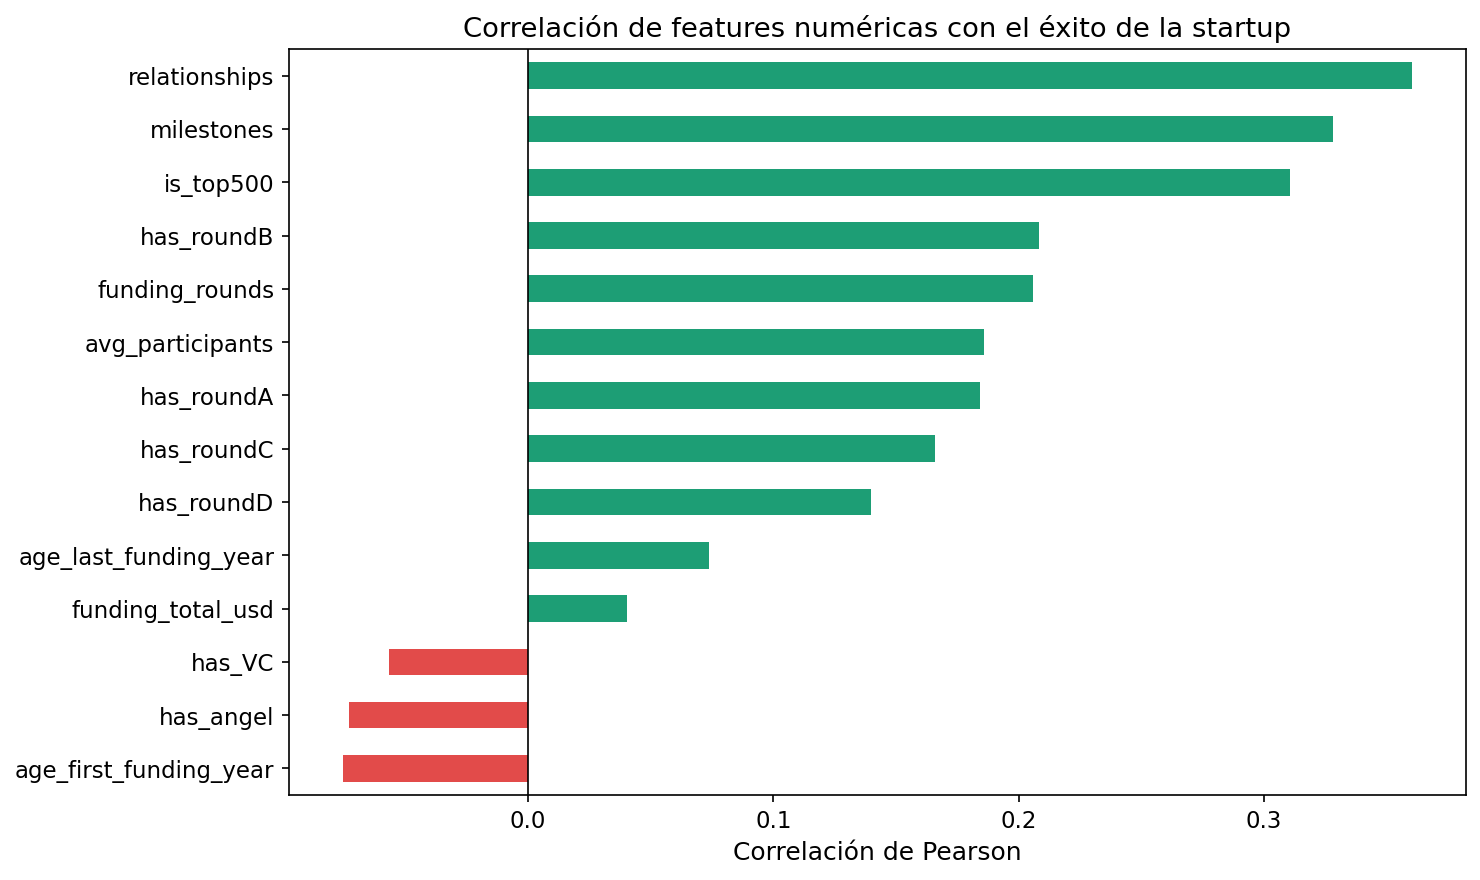


Top 5 features más correlacionadas con éxito:
relationships     0.360434
milestones        0.328260
is_top500         0.310652
has_roundB        0.208257
funding_rounds    0.206049
Name: labels, dtype: float64


In [7]:
# Seleccionar solo columnas numéricas relevantes
features_num = ['funding_rounds', 'funding_total_usd', 'relationships', 
                'milestones', 'avg_participants', 'is_top500',
                'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 
                'has_roundC', 'has_roundD', 'age_first_funding_year',
                'age_last_funding_year']

corr = df[features_num + ['labels']].corr()['labels'].drop('labels').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlación de features numéricas con el éxito de la startup')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../docs/fig_04_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nTop 5 features más correlacionadas con éxito:')
print(corr.abs().sort_values(ascending=False).head())

`relationships`, `milestones` e `is_top500` son los tres predictores más fuertes con correlaciones de 0.36, 0.33 y 0.31 respectivamente. Sorprendentemente, `has_angel` y `has_VC` correlacionan negativamente — startups que solo reciben inversión en etapa temprana sin avanzar a rondas A/B tienen mayor tendencia a cerrar.

## Conclusiones del EDA

**Dataset:** 923 startups — 597 acquired (64.7%) / 326 closed (35.3%)

**Hallazgos clave:**

1. Desbalance moderado 65/35, es decir, justifica aplicar SMOTE en el preprocesamiento
2. `relationships` y `milestones` son los predictores más fuertes de éxito
3. Startups con rondas A/B/C/D tienen mayor tasa de éxito que las que solo tienen angel o VC
4. `has_angel` y `has_VC` correlacionan negativamente, es decir, inversión en etapa temprana sin seguimiento = más riesgo
5. Columnas a eliminar en preprocesamiento: `Unnamed: 0`, `Unnamed: 6`, `id`, `name`, `object_id`, `zip_code`, `closed_at`, `state_code.1`

**Decisiones para el notebook 02:**
- Usar features numéricas + dummies de estado y categoría ya incluidos en el dataset
- Aplicar SMOTE únicamente sobre el train set para balancear clases
- Normalizar `funding_total_usd` y `age_first_funding_year` por su escala